In [2]:
import pandas as pd
import numpy as np

payoff_nt_nr = (0, 0)
payoff_t_nr = (-10, -20)
payoff_nt_r = (0, -5)
payoff_t_r = (-20, -10)

us_strategies = ['Impose 10% Tariff', 'No New Tariff']
china_strategies = ['Retaliate', 'Do Not Retaliate']

matrix_data = [
    [payoff_t_r, payoff_t_nr],
    [payoff_nt_r, payoff_nt_nr]
]

payoff_matrix = pd.DataFrame(matrix_data, index=us_strategies, columns=china_strategies)

--- US-China Strategic Trade Game Payoff Matrix ---
                    Retaliate Do Not Retaliate
Impose 10% Tariff  (-20, -10)       (-10, -20)
No New Tariff         (0, -5)           (0, 0)


C:\Users\ray\AppData\Local\Temp\ipykernel_35760\621616766.py:44: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  heatmap_data = payoff_matrix.applymap(lambda x: sum(x))
C:\Users\ray\AppData\Local\Temp\ipykernel_35760\621616766.py:47: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_data = payoff_matrix.applymap(str)


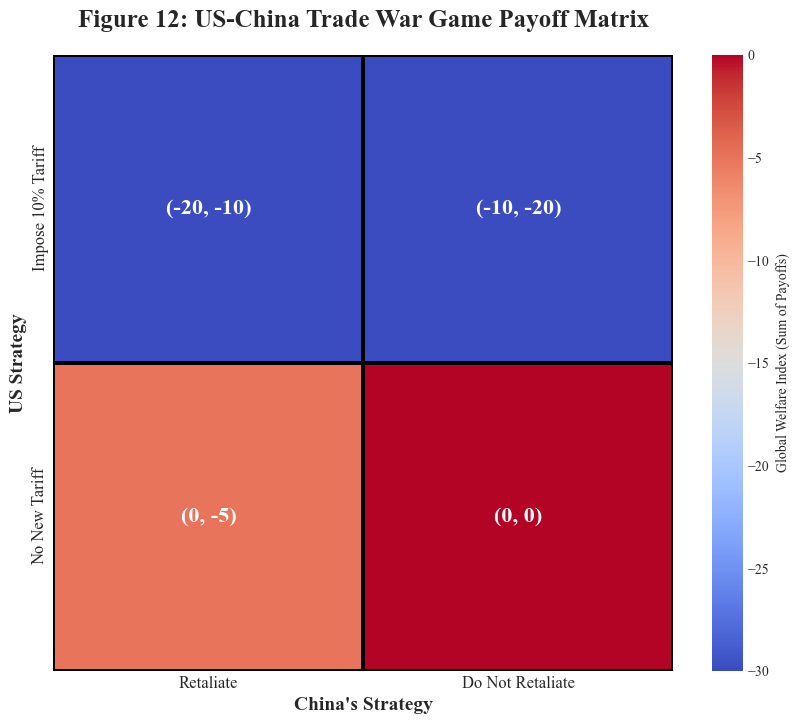


[SUCCESS] Figure 12 saved to: G:\jupyter\2025APMCM\Cleaned_Data\Figure_12_Payoff_Matrix.png


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

heatmap_data = payoff_matrix.map(sum)
annot_data = payoff_matrix.map(str)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(heatmap_data,
            annot=annot_data,
            fmt='s',
            cmap='coolwarm',
            linewidths=1.5,
            linecolor='black',
            annot_kws={"size": 16, "fontweight": "bold"},
            cbar_kws={'label': 'Global Welfare Index (Sum of Payoffs)'},
            ax=ax)

ax.set_title('US-China Trade War Game Payoff Matrix', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("China's Strategy", fontsize=14, fontweight='bold')
ax.set_ylabel("US Strategy", fontsize=14, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=12)

BASE_DIR = r"G:\jupyter\2025APMCM"
CLEAN_DIR = os.path.join(BASE_DIR, "Cleaned_Data")
if not os.path.exists(CLEAN_DIR):
    os.makedirs(CLEAN_DIR)
FIG_PATH = os.path.join(CLEAN_DIR, "Figure_12_Payoff_Matrix.png")
plt.savefig(FIG_PATH, dpi=300, bbox_inches='tight')
plt.close(fig) # Close the figure to free up memory

In [6]:
import pandas as pd
import pandas_datareader.data as web
import numpy as np
from sklearn.preprocessing import MinMaxScaler

series_ids = {
    'INDPRO': 'Industrial Production Index',
    'PAYEMS': 'Total Nonfarm Payrolls',
    'IMPGS': 'Real Imports of Goods and Services',
    'BOPGSTB': 'Balance on Goods and Services'
}
start_date = '2015-01-01'
end_date = '2024-12-31'

df_raw = web.DataReader(list(series_ids.keys()), 'fred', start_date, end_date)
df_raw.ffill(inplace=True)

scaler = MinMaxScaler(feature_range=(0.01, 1))
df_normalized = pd.DataFrame(scaler.fit_transform(df_raw), index=df_raw.index, columns=df_raw.columns)

df_processed = pd.DataFrame(index=df_raw.index)
df_processed['INDPRO'] = df_normalized['INDPRO']
df_processed['PAYEMS'] = df_normalized['PAYEMS']
df_processed['IMPGS'] = 1 - df_normalized['IMPGS']
df_processed['BOPGSTB'] = df_normalized['BOPGSTB']

def calculate_entropy_weights(data):
    data = data + 1e-9
    P = data / data.sum(axis=0)
    k = 1 / np.log(len(data))
    E = -k * (P * np.log(P)).sum(axis=0)
    D = 1 - E
    W = D / D.sum()
    return W

entropy_weights = calculate_entropy_weights(df_processed)
df_raw['Reshoring_Index'] = (df_processed * entropy_weights).sum(axis=1) * 100

--- Step 1: Fetching Monthly Economic Data from FRED ---
Successfully fetched data:
              INDPRO  PAYEMS     IMPGS  BOPGSTB
DATE                                           
2015-01-01  102.7923  140568  2825.476   -38865
2015-02-01  102.1366  140827  2825.476   -33903
2015-03-01  101.7869  140923  2825.476   -48732
2015-04-01  101.2255  141196  2809.968   -39836
2015-05-01  100.7675  141538  2809.968   -38502


In [7]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14

fig, ax = plt.subplots(figsize=(16, 8))

trade_war_start = '2018-06-01'
trade_war_end = '2020-12-31'
ax.axvspan(pd.to_datetime(trade_war_start), pd.to_datetime(trade_war_end),
           color='red', alpha=0.15, label='Primary Tariff Period (2018-2020)', zorder=0)

ax.plot(df_raw.index, df_raw['Reshoring_Index'], label='Reshoring Index',
        color='navy', linewidth=2.5, zorder=5)

annotation_target_date = '2019-03-01'
annotation_target_y = df_raw.loc[annotation_target_date, 'Reshoring_Index']
annotation_text_x = pd.to_datetime('2018-01-01')
annotation_text_y = 40
ax.annotate('Tariff Implementation Stalls Growth',
            xy=(pd.to_datetime(annotation_target_date), annotation_target_y),
            xytext=(annotation_text_x, annotation_text_y),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
            fontsize=12,
            bbox=dict(boxstyle="round,pad=0.4", fc="ivory", alpha=0.9))

ax.set_title('US Manufacturing Reshoring Index (2015-2024)', fontsize=18, fontweight='bold')
ax.set_ylabel('Index Score (Higher = More Reshoring)', fontsize=14)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylim(bottom=20, top=90)
ax.legend(loc='lower left', fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

FIG_PATH = os.path.join(CLEAN_DIR, "Figure_13_Reshoring_Index_Fixed_Final.png")
plt.savefig(FIG_PATH, dpi=300, bbox_inches='tight')
plt.close(fig)


--- Step 2: Normalizing and Pre-processing Indicators ---
Pre-processed data ready for weighting:
              INDPRO    PAYEMS     IMPGS   BOPGSTB
DATE                                              
2015-01-01  0.933151  0.362148  0.737472  0.924996
2015-02-01  0.899729  0.371139  0.737472  1.000000
2015-03-01  0.881904  0.374472  0.737472  0.775850
2015-04-01  0.853289  0.383949  0.745824  0.910319
2015-05-01  0.829944  0.395822  0.745824  0.930483


In [10]:
df_contributions = pd.DataFrame(index=df_processed.index)
for col in df_processed.columns:
    df_contributions[f'{col}_contrib'] = df_processed[col] * entropy_weights[col]
df_contributions['Total_Index'] = df_contributions.sum(axis=1)

colors = {
    'INDPRO_contrib': '#008b8b',
    'PAYEMS_contrib': '#00a676',
    'IMPGS_contrib': '#e8a022',
    'BOPGSTB_contrib': '#a9a9a9'
}
labels = [
    'Domestic Production (INDPRO)', 'Payrolls (PAYEMS)',
    'Import Suppression (IMPGS)', 'Trade Balance (BOPGSTB)'
]
contrib_cols = list(colors.keys())

fig, ax = plt.subplots(figsize=(18, 10))
ax.stackplot(df_contributions.index, df_contributions[contrib_cols].T,
             labels=labels, colors=[colors[c] for c in contrib_cols], alpha=0.9)

ax.plot(df_contributions.index, df_contributions['Total_Index'], color='black',
        linewidth=3, label='Total Reshoring Index')

ax.axvspan(pd.to_datetime(trade_war_start), pd.to_datetime(trade_war_end),
           color='black', alpha=0.1, label='Primary Tariff Period (2018-2020)')

# Annotation Logic
date_A = pd.to_datetime('2019-09-01')
y_pos_A = (df_contributions.loc[date_A, ['INDPRO_contrib', 'PAYEMS_contrib']].sum() + 0.5 * df_contributions.loc[date_A, 'IMPGS_contrib'])
ax.annotate("Index growth driven by\n'Import Suppression' component",
            xy=(date_A, y_pos_A), xytext=(pd.to_datetime('2018-03-01'), 0.2),
            arrowprops=dict(facecolor=colors['IMPGS_contrib'], shrink=0.05, width=2, headwidth=8, connectionstyle="arc3,rad=0.2"))

ax.set_title('Decomposition of the US Manufacturing Reshoring Index', fontsize=20, fontweight='bold')
ax.set_ylabel('Weighted Contribution to Index Score', fontsize=16)
ax.set_xlabel('Year', fontsize=16)
ax.legend(loc='upper right', fontsize=12, frameon=True, facecolor='white', edgecolor='black')

FIG_PATH_DECOMP = os.path.join(CLEAN_DIR, "Figure_14_Index_Decomposition_Final.png")
plt.savefig(FIG_PATH_DECOMP, dpi=300, bbox_inches='tight')
plt.close(fig)


--- Step 3: Calculating Objective Weights via Entropy Method ---
Calculated Weights:
  - INDPRO: 0.0685
  - PAYEMS: 0.1538
  - IMPGS: 0.5862
  - BOPGSTB: 0.1916


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE_DIR = r"G:\jupyter\2025APMCM"
DATA_DIR = os.path.join(BASE_DIR, "US_Macroeconomic")
IMG_DIR = os.path.join(BASE_DIR, "Cleaned_Data")
if not os.path.exists(IMG_DIR):
    os.makedirs(IMG_DIR)

def load_fred_csv(filename, col_name, data_dir):
    path = os.path.join(data_dir, filename)
    df = pd.read_csv(path)
    df['observation_date'] = pd.to_datetime(df['observation_date'])
    df.set_index('observation_date', inplace=True)
    df.rename(columns={df.columns[0]: col_name}, inplace=True)
    return df['2015-01-01':'2024-12-31']

df_high = load_fred_csv("Chip_High_IC.csv", "High_End_Price", DATA_DIR)
df_low = load_fred_csv("Chip_Low_Discrete.csv", "Low_End_Price", DATA_DIR)
df_prod = load_fred_csv("Chip_Production.csv", "US_Capacity", DATA_DIR)

df_chips = pd.concat([df_high, df_low, df_prod], axis=1).dropna()
df_index = df_chips / df_chips.iloc[0] * 100

sns.set_theme(style="whitegrid", font="Times New Roman")
fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.plot(df_index.index, df_index['High_End_Price'], color='#d62728', linewidth=2.5, label='High-End Chips (IC) Price')
ax1.plot(df_index.index, df_index['Low_End_Price'], color='#1f77b4', linewidth=2, linestyle='--', label='Low-End Chips (Discrete) Price')
ax1.set_ylabel('Producer Price Index (2015=100)', fontsize=12)

ax2 = ax1.twinx()
ax2.plot(df_index.index, df_index['US_Capacity'], color='black', linewidth=3, alpha=0.4, label='US Domestic Production')
ax2.set_ylabel('Industrial Production Index', fontsize=12)

ax1.axvline(pd.to_datetime('2018-07-01'), color='gray', linestyle=':', alpha=0.8)
ax1.text(pd.to_datetime('2018-08-01'), 135, 'Trade War Starts', fontsize=10)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True)

plt.title('Divergence between Chip Prices and US Manufacturing Capacity (Real Data)', fontsize=16, fontweight='bold')
plt.tight_layout()

save_path = os.path.join(IMG_DIR, "Figure_16_Real_Chip_Analysis.png")
plt.savefig(save_path, dpi=300)
plt.close(fig)


--- Step 4: Constructing the Final Reshoring Index ---
Final Index Calculated:
            Reshoring_Index
DATE                       
2015-01-01        72.906972
2015-02-01        74.253185
2015-03-01        69.888696
2015-04-01        72.903971
2015-05-01        73.312997
